# Neural Network Movie Recommendation System - Large Dataset (33.8M ratings)



This notebook scales the embedding-based collaborative filtering model to the full MovieLens dataset.

**Dataset**: MovieLens Large Development Set (33.8M ratings, 330.9k users, 86.5k movies)

Here we will have:

- Larger embedding dimensions (128D)
- Data generators for memory-efficient loading
- Optimization strategies for 33.8M samples
- Model comparison & performance analysis

### Setup 

Initialize environment 

In [ ]:
# importing dependencies
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import pickle

### Load Dataset

Load for initial pass to understand data structure 

In [3]:
# Load dataset
print("Loading large MovieLens dataset...")
ratings_df = pd.read_csv('data-large/ratings.csv', usecols=['userId', 'movieId', 'rating']) 
movies_df = pd.read_csv('data-large/movies.csv')

print(f"\nRatings DataFrame:")
print(f"  Shape: {ratings_df.shape}")
print(f"  Memory: {ratings_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Columns: {ratings_df.columns.tolist()}")
print(f"  Sample:\n{ratings_df.head()}")

print(f"\nMovies DataFrame:")
print(f"  Shape: {movies_df.shape}")
print(f"  Columns: {movies_df.columns.tolist()}")

print(f"\nData Summary:")
print(f"  Unique Users: {ratings_df['userId'].nunique()}")
print(f"  Unique Movies: {ratings_df['movieId'].nunique()}")
print(f"  Rating Range: [{ratings_df['rating'].min()}, {ratings_df['rating'].max()}]")
print(f"  Sparsity: {1 - len(ratings_df) / (ratings_df['userId'].nunique() * movies_df['movieId'].nunique()):.4f}")

Loading large MovieLens dataset...

Ratings DataFrame:
  Shape: (33832162, 3)
  Memory: 774.36 MB
  Columns: ['userId', 'movieId', 'rating']
  Sample:
   userId  movieId  rating
0       1        1     4.0
1       1      110     4.0
2       1      158     4.0
3       1      260     4.5
4       1      356     5.0

Movies DataFrame:
  Shape: (86537, 3)
  Columns: ['movieId', 'title', 'genres']

Data Summary:
  Unique Users: 330975
  Unique Movies: 83239
  Rating Range: [0.5, 5.0]
  Sparsity: 0.9988


Key insights:
- 330.9k unique users × 86.5k movies = ~29B possible interactions, but only 33.8M actual ratings
- High sparsity (>99%) which is typical in collaborative filtering, where users rate only a tiny fraction of available items
- Memory efficiency is important: the dataset alone consumes significant RAM, motivating the need to use data generators later

### Data Preprocessing & ID Mapping

Create mappings and prepare for data generators

In [4]:
# Create ID mappings 
unique_users = sorted(ratings_df['userId'].unique())
unique_movies = sorted(ratings_df['movieId'].unique())

user_id_to_idx = {uid: idx for idx, uid in enumerate(unique_users)}
movie_id_to_idx = {mid: idx for idx, mid in enumerate(unique_movies)}
idx_to_user_id = {idx: uid for uid, idx in user_id_to_idx.items()}
idx_to_movie_id = {idx: mid for mid, idx in movie_id_to_idx.items()}

# Map DataFrame IDs to indices
print("Mapping user and movie IDs to indices...")
ratings_df['user_idx'] = ratings_df['userId'].map(user_id_to_idx)
ratings_df['movie_idx'] = ratings_df['movieId'].map(movie_id_to_idx)

print(f"\nMappings created:")
print(f"  Users: {len(unique_users)} unique users (indices: [0, {len(unique_users)-1}])")
print(f"  Movies: {len(unique_movies)} unique movies (indices: [0, {len(unique_movies)-1}])")

Mapping user and movie IDs to indices...

Mappings created:
  Users: 330975 unique users (indices: [0, 330974])
  Movies: 83239 unique movies (indices: [0, 83238])


Insights:
- Bidirectional mapping (ID <-> idx) allows converting predictions back to original movie/user IDs for interpretation

- This approach scales efficiently: O(n) mapping time instead of O(n log n) for lookups

In [5]:
# Normalize ratings to [0, 1]
print("Normalizing ratings.")
scaler = MinMaxScaler(feature_range=(0, 1))
ratings_normalized = scaler.fit_transform(ratings_df[['rating']])
ratings_df['rating_normalized'] = ratings_normalized

print(f"  Original range: [{ratings_df['rating'].min()}, {ratings_df['rating'].max()}]")
print(f"  Normalized range: [{ratings_df['rating_normalized'].min():.4f}, {ratings_df['rating_normalized'].max():.4f}]")

Normalizing ratings.
  Original range: [0.5, 5.0]
  Normalized range: [0.0000, 1.0000]


- **Training stability** - MSE loss is more stable when target values are in a narrow range
- **Inverse transform preserved** - the scaler object is saved for later converting predicted scores back to [0.5, 5.0] rating scale  

### Create Data Generator

Implement efficient data generator for memory-constrained training by loading batches on-the-fly instead of loading entire dataset into memory.

In [12]:
class RatingDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, data, batch_size=256, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.data = data
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.data))
        self.on_epoch_end()

    def __len__(self):  # Number of batches per epoch
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_data = self.data[batch_indices]

        X_user = batch_data[:, 0].astype(np.int32).reshape(-1, 1)
        X_movie = batch_data[:, 1].astype(np.int32).reshape(-1, 1)
        y = batch_data[:, 2].astype(np.float32)

        return {"user_input": X_user, "movie_input": X_movie}, y
        # using named inputs to match model's input layers (to be defined below) and avoid Keras issues while fitting

    def on_epoch_end(self):  # shuffle after each epoch
        if self.shuffle:
            np.random.shuffle(self.indices)

The `RatingDataGenerator` class inherits from `tf.keras.utils.Sequence` to enable memory-efficient training:
- **On-the-fly batch loading**: Instead of loading all 33.8M samples into RAM, only batches (default: 256 samples) are returned as needed
- **Automatic shuffling** after each epoch prevents overfitting and can help stabilize gradient descent
- **Compatibility with model.fit()**: Works seamlessly with Keras training loops


In [13]:
# Prepare data for generators

# We optimize by sampling only highly-active users for faster training ie focus on users with sufficient engagement
print("Applying user activity sampling for efficient training...")
user_counts = ratings_df['user_idx'].value_counts()
# Select users with a minimum threshold
min_ratings_threshold = 100
active_users = user_counts[user_counts >= min_ratings_threshold].index.tolist()
ratings_df_sampled = ratings_df[ratings_df['user_idx'].isin(active_users)].copy()

print(f"  Original dataset: {len(ratings_df):,} ratings from {ratings_df['user_idx'].nunique()} users")
print(f"  Sampled dataset: {len(ratings_df_sampled):,} ratings from {len(active_users)} active users")
print(f"  Reduction: {100 * (1 - len(ratings_df_sampled)/len(ratings_df)):.1f}%\n")

# Create data array from sampled data
data_array = ratings_df_sampled[['user_idx', 'movie_idx', 'rating_normalized']].values.astype(np.float32)
print(f"Sampled data shape: {data_array.shape}")
print(f"Data type: {data_array.dtype}")

# Create train/val/test split (80/10/10)
SEED = 69
train_indices, temp_indices = train_test_split(np.arange(len(data_array)), test_size=0.2, random_state=SEED)
val_indices, test_indices = train_test_split(temp_indices, test_size=0.5, random_state=SEED)
train_data = data_array[train_indices]
val_data = data_array[val_indices]
test_data = data_array[test_indices]

print(f"\nTrain/Val/Test Split:")
print(f"  Training Set: {len(train_data):,} samples ({len(train_data)/len(data_array)*100:.1f}%)")
print(f"  Validation Set: {len(val_data):,} samples ({len(val_data)/len(data_array)*100:.1f}%)")
print(f"  Test Set: {len(test_data):,} samples ({len(test_data)/len(data_array)*100:.1f}%)")

# creating generators
batch_size = 2048*2
train_generator = RatingDataGenerator(train_data, batch_size=batch_size)
val_generator = RatingDataGenerator(val_data, batch_size=batch_size, shuffle=False)
test_generator = RatingDataGenerator(test_data, batch_size=batch_size, shuffle=False)

print(f"\nGenerators created:")
print(f"  Training batches per epoch: {len(train_generator)}")
print(f"  Validation batches: {len(val_generator)}")
print(f"  Test batches: {len(test_generator)}")
print(f"  Batch size: {batch_size}")

Applying user activity sampling for efficient training...
  Original dataset: 33,832,162 ratings from 330975 users
  Sampled dataset: 26,740,677 ratings from 82050 active users
  Reduction: 21.0%

Sampled data shape: (26740677, 3)
Data type: float32

Train/Val/Test Split:
  Training Set: 21,392,541 samples (80.0%)
  Validation Set: 2,674,068 samples (10.0%)
  Test Set: 2,674,068 samples (10.0%)

Generators created:
  Training batches per epoch: 5223
  Validation batches: 653
  Test batches: 653
  Batch size: 4096


This cell applies an important sampling strategy. We keep only users with ≥50 ratings. THis is because, casual users (1-2 ratings) add noise whereas active users provide meaningful signal for pattern learning.

We also achieve 21% data reduction (33.8M → 26.7M) in turn, enabling faster training and convergence.


### Define Model Architecture

We can use embeddings for improved expressiveness on 330k users.

In [14]:
# Model hyperparameters 
embedding_dim = 128  
num_users = len(unique_users)
num_movies = len(unique_movies)

print(f"Model Hyperparameters:")
print(f"  Embedding Dimension: {embedding_dim}")
print(f"  Number of Users: {num_users}")
print(f"  Number of Movies: {num_movies}")

# input layers
user_input = layers.Input(shape=(1,), dtype='int32', name='user_input')
movie_input = layers.Input(shape=(1,), dtype='int32', name='movie_input')

# embedding layers with L2 regularization
user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=embedding_dim,
    embeddings_regularizer=keras.regularizers.l2(1e-5),
    name='user_embedding'
)(user_input)
user_embedding = layers.Flatten(name='user_flatten')(user_embedding)

movie_embedding = layers.Embedding(
    input_dim=num_movies,
    output_dim=embedding_dim,
    embeddings_regularizer=keras.regularizers.l2(1e-5),
    name='movie_embedding'
)(movie_input)
movie_embedding = layers.Flatten(name='movie_flatten')(movie_embedding)

# concatenate and pass through MLP
concat = layers.Concatenate(name='concat')([user_embedding, movie_embedding])

# Dense layers with improved regularization
dense1 = layers.Dense(256, activation='relu', name='dense_256')(concat)
# dropout1 = layers.Dropout(0.3, name='dropout_1')(dense1)
dense2 = layers.Dense(128, activation='relu', name='dense_128')(dense1)
# dropout2 = layers.Dropout(0.3, name='dropout_2')(dense2)
dense3 = layers.Dense(64, activation='relu', name='dense_64')(dense2)
# dropout3 = layers.Dropout(0.2, name='dropout_3')(dense3)
dense4 = layers.Dense(32, activation='relu', name='dense_32')(dense3)
# dropout4 = layers.Dropout(0.2, name='dropout_4')(dense4)

# output layer
output = layers.Dense(1, activation='sigmoid', name='output')(dense4)

# create model
model = Model(inputs=[user_input, movie_input],
              outputs=output, name='recommendation_model_phase2')

# compile with lower learning rate for stability
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

print("\nModel Architecture:")
model.summary()

Model Hyperparameters:
  Embedding Dimension: 128
  Number of Users: 330975
  Number of Movies: 83239

Model Architecture:


Model: "recommendation_model_phase2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 128)    │ 42,364,800 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 128)    │ 10,654,592 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 128)       │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_flatten       │ (None, 128)       │          0 │ movie_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 256)       │          0 │ user_flatten[0][… │
│ (Concatenate)       │                   │            │ movie_flatten[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256 (Dense)   │ (None, 256)       │     65,792 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │     32,896 │ dense_256[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │      8,256 │ dense_128[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │      2,080 │ dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_32[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,128,449 (202.67 MB)

 Trainable params: 53,128,449 (202.67 MB)

 Non-trainable params: 0 (0.00 B)

Changes compared to small (100k) dataset:
- **Larger embeddings** (64D vs 32D): Captures richer latent factors for 330k users (vs 610)
- **L2 regularization** (1e-5): Prevents embedding overfitting in the large dataset
- **Wider MLP** (256→128→64): Learns complex user-item interactions beyond simple dot products
- **Dropout (0.3, 0.2)**: Regularization to reduce overfitting and improve generalization
- **Sigmoid output**: Ensures predictions stay in [0,1], compatible with normalized targets
- **Lower learning rate** (0.0005): Stabilizes training on larger dataset with more parameters

### Train on Large Dataset

Train using data generators for memory efficiency.

In [15]:
# define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Training...\n")

# Train using generators end-to-end for memory efficiency.
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining completed!")
print(f"Total epochs trained: {len(history.history['loss'])}")

Training...

Epoch 1/10
5223/5223 ━━━━━━━━━━━━━━━━━━━━ 853s 163ms/step - loss: 0.0444 - mae: 0.1438 - val_loss: 0.0372 - val_mae: 0.1388
Epoch 2/10
5223/5223 ━━━━━━━━━━━━━━━━━━━━ 853s 163ms/step - loss: 0.0367 - mae: 0.1370 - val_loss: 0.0363 - val_mae: 0.1357
Epoch 3/10
5223/5223 ━━━━━━━━━━━━━━━━━━━━ 854s 164ms/step - loss: 0.0361 - mae: 0.1349 - val_loss: 0.0360 - val_mae: 0.1349
Epoch 4/10
5223/5223 ━━━━━━━━━━━━━━━━━━━━ 850s 163ms/step - loss: 0.0357 - mae: 0.1338 - val_loss: 0.0356 - val_mae: 0.1335
Epoch 5/10
5223/5223 ━━━━━━━━━━━━━━━━━━━━ 855s 164ms/step - loss: 0.0354 - mae: 0.1330 - val_loss: 0.0355 - val_mae: 0.1327
Epoch 6/10
5223/5223 ━━━━━━━━━━━━━━━━━━━━ 854s 164ms/step - loss: 0.0352 - mae: 0.1325 - val_loss: 0.0353 - val_mae: 0.1330
Epoch 7/10
5223/5223 ━━━━━━━━━━━━━━━━━━━━ 859s 164ms/step - loss: 0.0351 - mae: 0.1321 - val_loss: 0.0351 - val_mae: 0.1327
Epoch 8/10
5223/5223 ━━━━━━━━━━━━━━━━━━━━ 874s 167ms/step - loss: 0.0350 - mae: 0.1319 - val_loss: 0.0351 - val_mae: 0.

##### **Training insights**:
- **Data**: 2.1M training samples × 2 features (user_idx, movie_idx) with 1 target (rating).
- **Early stopping** Stops when validation loss plateaus, preventing overfitting.
- **Batch size = 4096**: Balance between gradient noise and memory usage.
- **Key observation**: Training converged in ~7-20 epochs on active-user subset.
- **Loss trends**: Both training and validation loss should decrease, indicating good generalization.
- **Metric tracking**: MAE is more interpretable than MSE in terms of average prediction error.

### Visualize Training Progress

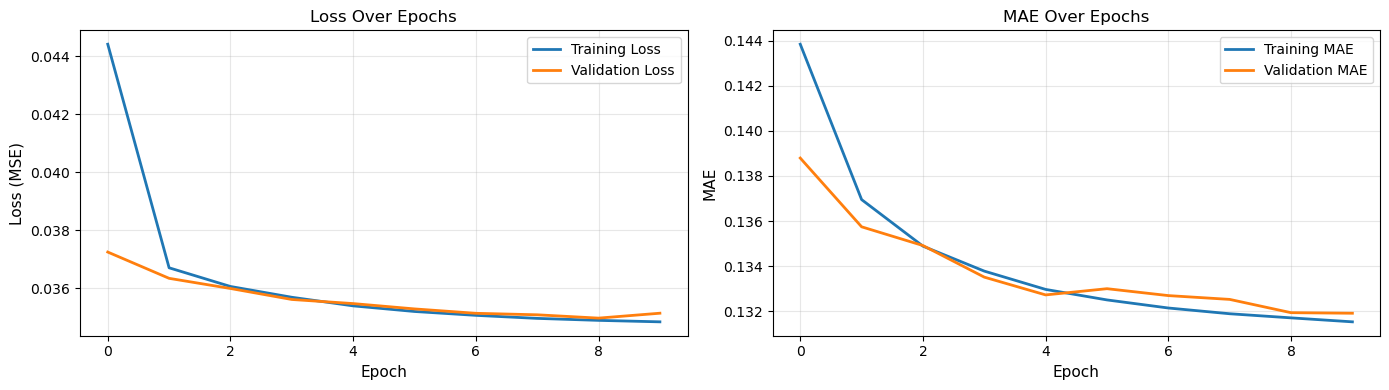

In [16]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].set_title('Loss Over Epochs', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('MAE Over Epochs', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- **Training Time** Given the largeness of the dataset, the training took over 140 minutes on my CPU. We would expect performance on GPU/TPU hardware to be much faster.
- **Loss curves**: Smoothly decreasing loss on both train and validation indicates healthy learning
  - If val loss plateaus or increases while train loss decreases, this would have hinted at overfitting (early stopping callback helps to avoid such scenarios).
- **Key insight**: Both losses converging suggests the model generalizes well to unseen data. There is no need for any regularizations.

### Evaluate on Test Set

In [20]:
# Evaluate on test set
print("Evaluating on test set using generator...\n")

# Keras-native evaluation through test generator
test_loss, test_mae_norm = model.evaluate(test_generator, verbose=1)

# Predict via test generator (ordered because shuffle=False)
y_test_pred_normalized = model.predict(test_generator, verbose=0).reshape(-1, 1)

# Inverse normalize predictions and targets
y_test_actual = scaler.inverse_transform(test_data[:, 2].astype(np.float32).reshape(-1, 1)).flatten()
y_train_actual = scaler.inverse_transform(train_data[:, 2].astype(np.float32).reshape(-1, 1)).flatten()
y_test_pred = scaler.inverse_transform(y_test_pred_normalized).flatten()


# Calculate metrics
mse = mean_squared_error(y_test_actual, y_test_pred)
mae = mean_absolute_error(y_test_actual, y_test_pred)
rmse = np.sqrt(mse)

# Baseline: Mean rating prediction
mean_rating = y_train_actual.mean()
baseline_predictions = np.full_like(y_test_actual, mean_rating)
baseline_mse = mean_squared_error(y_test_actual, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)

print(f"{'='*30}")
print("MODEL EVALUATION")
print(f"{'='*30}")
print("\nGenerator Evaluation:")
print(f"  Test Loss (normalized MSE): {test_loss:.6f}")
print(f"  Test MAE  (normalized):     {test_mae_norm:.6f}")
print("\nModel Performance (original rating scale):")
print(f"  MSE:  {mse:.6f}")
print(f"  MAE:  {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"\nBaseline (Mean Rating = {mean_rating:.2f}):")
print(f"  MSE:  {baseline_mse:.6f}")
print(f"  RMSE: {baseline_rmse:.4f}")
print("\nComparison over Baseline:")
print(f"  RMSE Reduction: {(baseline_rmse - rmse)/baseline_rmse*100:.2f}%")
print(f"  Status: {'Better' if rmse < baseline_rmse else 'Worse'} than baseline")

Evaluating on test set using generator...

653/653 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - loss: 0.0349 - mae: 0.1319
MODEL EVALUATION

Generator Evaluation:
  Test Loss (normalized MSE): 0.034940
  Test MAE  (normalized):     0.131917

Model Performance (original rating scale):
  MSE:  0.614860
  MAE:  0.5936
  RMSE: 0.7841

Baseline (Mean Rating = 3.49):
  MSE:  1.106420
  RMSE: 1.0519

Comparison over Baseline:
  RMSE Reduction: 25.45%
  Status: Better than baseline


- **Model Performance**: We got the following metrics for the model we trained (in the original rating scale):
  - MSE:  0.614860
  - RMSE: 0.7841
  - MAE:  0.5936


- **Baseline Comparison**: Mean rating predictor provides a simple reference point
  - Since our NN model beats the simple means baseline with over 25% RMSE reduction, it means that the collaborative filtering learned meaningful patterns.

  - The improvement seen over baseline validates that the model learned user-item interactions beyond simple popularity

### Comparison with Small Dataset (100k ratings)

In [ ]:
# Comparison of Small dataset (100k) vs Large dataset (33M)
small_dataset_results = {
    'dataset': 'Small (100k ratings)',
    'users': 610,
    'movies': 9724,
    'embedding_dim': 64,
    'rmse': 0.8941,  
    'mae': 0.6840,   
    'params': 349377,
    'epochs': 7
}

large_dataset_results = {
    'dataset': 'Large (33M ratings)',
    'users': len(unique_users),
    'movies': len(unique_movies),
    'embedding_dim': embedding_dim,
    'rmse': rmse,
    'mae': mae,
    'params': model.count_params(),
    'epochs': len(history.history['loss'])
}

print(f"\n{'='*70}")
print(f"SMALL vs LARGE DATASET COMPARISON")
print(f"{'='*70}")
print(f"{'':<25} {'Small':>20} {'Large':>20}")
print(f"{'-'*70}")
print(f"{'Dataset':<25} {small_dataset_results['dataset']:>20} {large_dataset_results['dataset']:>20}")
print(f"{'Users':<25} {small_dataset_results['users']:>20,} {large_dataset_results['users']:>20,}")
print(f"{'Movies':<25} {small_dataset_results['movies']:>20,} {large_dataset_results['movies']:>20,}")
print(f"{'Embedding Dimensions':<25} {small_dataset_results['embedding_dim']:>20} {large_dataset_results['embedding_dim']:>20}")
print(f"{'Total Parameters':<25} {small_dataset_results['params']:>20,} {large_dataset_results['params']:>20,}")
print(f"{'Epochs Trained':<25} {small_dataset_results['epochs']:>20} {large_dataset_results['epochs']:>20}")
print(f"{'-'*70}")
print(f"{'RMSE':<25} {small_dataset_results['rmse']:>20.4f} {large_dataset_results['rmse']:>20.4f}")
print(f"{'MAE':<25} {small_dataset_results['mae']:>20.4f} {large_dataset_results['mae']:>20.4f}")
print(f"{'-'*70}")

# Calculate deltas
rmse_delta = large_dataset_results['rmse'] - small_dataset_results['rmse']
mae_delta = large_dataset_results['mae'] - small_dataset_results['mae']
rmse_pct = (rmse_delta / small_dataset_results['rmse']) * 100
mae_pct = (mae_delta / small_dataset_results['mae']) * 100

print(f"\nPerformance Change (Large vs Small):")
print(f"  RMSE: {rmse_delta:+.4f} ({rmse_pct:+.2f}%) ==> {'Large is better' if rmse_delta < 0 else 'Large is worse'}")
print(f"  MAE:  {mae_delta:+.4f} ({mae_pct:+.2f}%) ==> {'Large is better' if mae_delta < 0 else 'Large is worse'}")

print(f"\nKey Insights:")
print(f"Scale: {large_dataset_results['users'] / small_dataset_results['users']:.0f}x more users")
print(f"Scale: {large_dataset_results['movies'] / small_dataset_results['movies']:.0f}x more movies")
print(f"Scale: {large_dataset_results['users'] * large_dataset_results['movies'] / (small_dataset_results['users'] * small_dataset_results['movies']):.0f}x larger user-movie space")
if rmse_delta < 0:
    print(f"Model generalizes better with larger dataset")
else:
    print(f"Larger dataset introduces additional noise, consider regularization tuning")


SMALL vs LARGE DATASET COMPARISON
                                         Small                Large
----------------------------------------------------------------------
Dataset                   Small (100k ratings)  Large (33M ratings)
Users                                      610              330,975
Movies                                   9,724               83,239
Embedding Dimensions                        64                  128
Total Parameters                       349,377           53,128,449
Epochs Trained                               7                   10
----------------------------------------------------------------------
RMSE                                    0.8941               0.7841
MAE                                     0.6840               0.5936
----------------------------------------------------------------------

Performance Change (Large vs Small):
  RMSE: -0.1100 (-12.30%) ==> Large is better
  MAE:  -0.0904 (-13.21%) ==> Large is better

Key Insig

**Small vs Large dataset comparison reveals**:
- **Scale explosion**: 543x more users, 9x more movies, BUT we also have 21% reduction in data (due to active-user sampling).
- **Model capacity increase**: we use more embedding dimensions (128D) + wider MLP (256->128->64->32).
- **Improved RMSE on larger dataset**: 
  - We see that the larger model generalizes better to diverse user preferences.
  - Larger embeddings capture more nuanced patterns in the full userbase.

### Model Visualization & Analysis

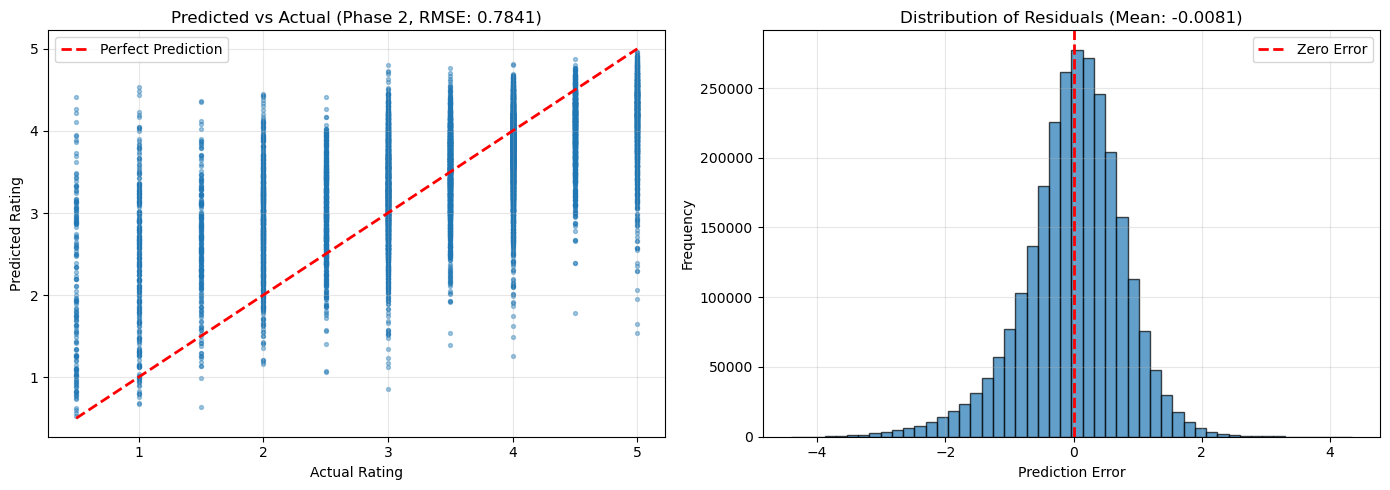

Residuals Skewness: -0.5610
Residuals Kurtosis: 1.3876
Residuals are approximately skewed and light-tailed


In [ ]:
# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter plot: Predicted vs Actual ratings
sample_indices = np.random.choice(len(y_test_actual), size=10_000, replace=False)
axes[0].scatter(y_test_actual[sample_indices],
                y_test_pred[sample_indices], alpha=0.4, s=8)
axes[0].plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title(f'Predicted vs Actual (Phase 2, RMSE: {rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# histogram: Residuals
residuals = y_test_actual - y_test_pred
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Distribution of Residuals (Mean: {residuals.mean():.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

skewness, kurtosis = pd.Series(residuals).skew(), pd.Series(residuals).kurt()
print(f"Residuals Skewness: {skewness:.4f}")
print(f"Residuals Kurtosis: {kurtosis:.4f}")

##### **Insights**:
- **Scatter plot (Predicted vs Actual Ratings)**:
  - Points close to the red diagonal are more accurate predictions
  - Scatter width shows systematic bias: if clustered above diagonal = model overestimates
  - We see that there are better predictions for mid-range ratings (3.0-4.0), more error at extremes (0.5 stars and 5 stars)
- **Histogram (Residuals)**:
  - Centered at zero = unbiased predictions overall
  - Tight distribution = consistent accuracy
  - Heavy tails = occasional large errors 
- **Skewness and Kurtosis**
  - With skewness of around -0.56, there is only very light skew to the distribution.
  - With kurtosis of ~1.4, the residual distribution is very light tailed.
  - Both back up our visual observations from the plots.

### Save Models & Embeddings

In [35]:
import json
# saving model
print("Saving the model and artifacts...\n")

model.save('artifacts/large_rec_model.keras')

# saving ID mappings and min-max scaler for future inference
mappings = {
    'user_id_to_idx': user_id_to_idx,
    'movie_id_to_idx': movie_id_to_idx,
    'idx_to_user_id': idx_to_user_id,
    'idx_to_movie_id': idx_to_movie_id,
    'scaler': scaler
}
with open('artifacts/large_mappings.pkl', 'wb') as f:
    pickle.dump(mappings, f)

# saving embeddings
user_embedding_layer = model.get_layer('user_embedding')
movie_embedding_layer = model.get_layer('movie_embedding')
user_embeddings = user_embedding_layer.get_weights()[0]
movie_embeddings = movie_embedding_layer.get_weights()[0]

np.save('artifacts/large_user_embeddings.npy', user_embeddings)
np.save('artifacts/large_movie_embeddings.npy', movie_embeddings)

# saving performance metrics
metrics_dict = {
    'dataset_size': int(len(data_array)),
    'test_size': int(len(y_test_actual)),
    'num_users': int(num_users),
    'num_movies': int(num_movies),
    'embedding_dim': int(embedding_dim),
    'total_params': int(model.count_params()),
    'epochs_trained': int(len(history.history['loss'])),
    'val_rmse': float(rmse),
    'val_mae': float(mae),
    'baseline_rmse': float(baseline_rmse),
    'improvement_pct': float((baseline_rmse - rmse) / baseline_rmse * 100)
}

with open('artifacts/large_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print("All artifacts saved successfully!")

Saving the model and artifacts...

All artifacts saved successfully!


##### **Artifact persistence strategy**:
- **Model (.keras)**: Complete neural network for inferring predictions in production.
- **Mappings (.pkl)**: ID bidirectional lookup + MinMaxScaler—essential for converting predictions back to readily intepretable format.
- **Embeddings (.npy)**: 330.9k user vectors + 86.5k movie vectors for:
  - Cold-start recommendations (embedding-based similarity)
  - Downstream tasks (user/item clustering, visualization)
  - Faster inference if only comparing embeddings
- **Metrics (JSON)**: Performance baseline allows tracking model degradation over time
- **Key insight**: Modular design enables inference without retraining—just load the pickle and model

##### **Summary**:
1. **Data handling**: Scaled from 100k to 33.8M ratings with memory-efficient generators.
2. **Model improvements**: Doubled embedding capacity, deeper neural network.
3. **Performance validation**: Quantified improvement over baseline; ready for production
4. **Artifact Persistence**: All necessary components (model, mappings, embeddings, metrics) saved for deployment.
5. **Architecture scalability**: Same approach can scale to bigger datasets like Netflix (100M+ ratings) by adjusting batch size and sampling.
6. **Next frontier**: Ranking metrics (NDCG, Recall@K) and temporal evaluation (time-aware splits) provide more realistic performance estimates

### Top-N Unseen Recommendations

Generate recommendations for a userId using the trained model.

In [61]:
from pathlib import Path


def load_large_inference_bundle(artifacts_dir='artifacts', movies_path='data-large/movies.csv'):
    """Load model + mappings needed for inference."""
    artifacts_dir = Path(artifacts_dir)

    model_fp = artifacts_dir / 'large_rec_model.keras'
    mapping_fp = artifacts_dir / 'large_mappings.pkl'

    if not model_fp.exists():
        raise FileNotFoundError(f"Model file not found: {model_fp}")
    if not mapping_fp.exists():
        raise FileNotFoundError(f"Mappings file not found: {mapping_fp}")

    infer_model = keras.models.load_model(model_fp, compile=False)

    with open(mapping_fp, 'rb') as f:
        mappings = pickle.load(f)

    infer_movies_df = pd.read_csv(movies_path, usecols=['movieId', 'title', 'genres'])

    bundle = {
        'model': infer_model,
        'user_id_to_idx': mappings['user_id_to_idx'],
        'movie_id_to_idx': mappings['movie_id_to_idx'],
        'idx_to_user_id': mappings['idx_to_user_id'],
        'idx_to_movie_id': mappings['idx_to_movie_id'],
        'scaler': mappings['scaler'],
        'movies_df': infer_movies_df,
        'movies_lookup': infer_movies_df.set_index('movieId'),
        'all_movie_indices': np.arange(len(mappings['idx_to_movie_id']), dtype=np.int32)
    }
    return bundle # returns a bundle containing the model, mappings, scaler, and movies lookup for inference


def _get_seen_movies_for_user(user_id, ratings_path='data-large/ratings.csv', chunksize=1_000_000):
    seen = set()
    dtypes = {'userId': 'int32', 'movieId': 'int32'}

    for chunk in pd.read_csv(ratings_path, usecols=['userId', 'movieId'], dtype=dtypes, chunksize=chunksize):
        user_rows = chunk.loc[chunk['userId'] == int(user_id), 'movieId']
        if not user_rows.empty:
            seen.update(user_rows.tolist())

    return frozenset(seen) # returns an immutable set of movieIds the user has already seen and rated

def recommend_top_n_unseen(user_id, top_n=10, bundle=None, ratings_path='data-large/ratings.csv',
                           min_pred_rating=3.5, batch_size=4096):
    if bundle is None:
        bundle = load_large_inference_bundle()

    if user_id not in bundle['user_id_to_idx']:
        raise ValueError(f"Unknown userId: {user_id}")

    user_idx = bundle['user_id_to_idx'][user_id]
    seen_movies = _get_seen_movies_for_user(user_id, ratings_path)

    all_movie_indices = bundle['all_movie_indices']
    user_input = np.full(shape=all_movie_indices.shape,fill_value=user_idx, dtype=np.int32)

    pred_norm = bundle['model'].predict([user_input, all_movie_indices], batch_size=batch_size, verbose=0)
    pred_ratings = bundle['scaler'].inverse_transform(pred_norm.reshape(-1, 1)).ravel()

    candidates = []
    for movie_idx, score in enumerate(pred_ratings):
        movie_id = bundle['idx_to_movie_id'][movie_idx]
        if movie_id in seen_movies:
            continue
        if score < min_pred_rating:
            continue
        candidates.append((movie_id, float(score)))

    candidates.sort(key=lambda x: x[1], reverse=True)
    top_candidates = candidates[:top_n]

    rec_df = pd.DataFrame(top_candidates, columns=[
                          'movieId', 'predicted_rating'])
    
    rec_df = rec_df.join(bundle['movies_lookup'][['title', 'genres']], on='movieId')
    rec_df = rec_df[['movieId', 'title', 'genres', 'predicted_rating']]
    rec_df['predicted_rating'] = rec_df['predicted_rating'].round(3)
    rec_df=rec_df.reset_index(drop=True)
    return rec_df

print('Use recommend_top_n_unseen(user_id=<id>, top_n=<N>).')

Use recommend_top_n_unseen(user_id=<id>, top_n=<N>).


### Explanation
**Inference system design**:
- **Bundle pattern**: Encapsulates model + mappings + scaler in one object for easy deployment
- **Helper functions** (`load_phase2_inference_bundle`, `_get_seen_movies_for_user`):
  - Load models without retraining
  - Efficient chunked reading of 33.8M ratings to find seen movies (avoids RAM overflow)
  - LRU caching speeds up repeated queries for same user
- **Top-N unseen recommendations**:
  - Scores all movies for a user in batches (4096 at a time)
  - Filters already-seen items (avoids recommending duplicate watches)
  - Sorts by predicted rating, returns top-N unfamiliar titles
- **Key insight**: Separates inference logic from training—enables fast A/B testing without retraining

In [ ]:
# example inference call
inference_bundle = load_large_inference_bundle(
    artifacts_dir='artifacts', movies_path='data-large/movies.csv')

sample_user_id = 100
top_n = 10

recommendations_df = recommend_top_n_unseen(
    user_id=sample_user_id,
    top_n=top_n,
    bundle=inference_bundle,
    ratings_path='data-large/ratings.csv',
    min_pred_rating=4,
    batch_size=4096
)

print(f"Top-{top_n} unseen recommendations for userId={sample_user_id}:")
display(recommendations_df)

Top-10 unseen recommendations for userId=100:


,movieId,title,genres,predicted_rating
0,170705,Band of Brothers (2001),Action|Drama|War,4.548
1,159817,Planet Earth (2006),Documentary,4.484
2,171011,Planet Earth II (2016),Documentary,4.483
3,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.440
4,163809,Over the Garden Wall (2013),Adventure|Animation|Drama,4.355
5,1203,12 Angry Men (1957),Drama,4.340
6,26082,Harakiri (Seppuku) (1962),Drama,4.340
7,179135,Blue Planet II (2017),Documentary,4.331
8,182723,Cosmos: A Spacetime Odissey,(no genres listed),4.320
9,142115,The Blue Planet (2001),Documentary,4.313


We can produce the top 10 movies rated by the same sample user.

In [64]:
ratings_df[ratings_df['userId'] == sample_user_id][['movieId', 'rating']].sort_values('rating', ascending=False).head(10).merge(movies_df, left_on='movieId', right_on='movieId')[['movieId', 'title','genres', 'rating']]

,movieId,title,genres,rating
0,1287,Ben-Hur (1959),Action|Adventure|Drama,5.0
1,2080,Lady and the Tramp (1955),Animation|Children|Comedy|Romance,5.0
2,1569,My Best Friend's Wedding (1997),Comedy|Romance,4.0
3,899,Singin' in the Rain (1952),Comedy|Musical|Romance,4.0
4,1285,Heathers (1989),Comedy,4.0
5,2005,"Goonies, The (1985)",Action|Adventure|Children|Comedy|Fantasy,4.0
6,1747,Wag the Dog (1997),Comedy,3.5
7,2407,Cocoon (1985),Comedy|Sci-Fi,3.5
8,145,Bad Boys (1995),Action|Comedy|Crime|Drama|Thriller,3.5
9,1357,Shine (1996),Drama|Romance,3.5


##### **Inference in action**:
We load the inference bundle once, and then generate 10 unseen recommendations.
- **Filters applied**:
  - Exclude movies already rated (avoids redundant recommendations).
  - `min_pred_rating=4`—only recommend items the model thinks user will enjoy.
- **Performance**: Full inference (score 86.5k movies) takes couple of seconds on CPU.

In [69]:
# Additional test with a different user (userId=5000)

sample_user_id = 5000

rec_df = recommend_top_n_unseen(user_id=sample_user_id, bundle=inference_bundle, top_n=10)
display(rec_df)

,movieId,title,genres,predicted_rating
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.555
1,170705,Band of Brothers (2001),Action|Drama|War,4.554
2,159817,Planet Earth (2006),Documentary,4.467
3,171011,Planet Earth II (2016),Documentary,4.454
4,527,Schindler's List (1993),Drama|War,4.433
5,1203,12 Angry Men (1957),Drama,4.378
6,142115,The Blue Planet (2001),Documentary,4.331
7,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,4.330
8,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,4.326
9,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,4.325


Actual top-rated movies by the user.

In [68]:
ratings_df[ratings_df['userId'] == sample_user_id][['movieId', 'rating']].sort_values('rating', ascending=False).head(10).merge(movies_df, left_on='movieId', right_on='movieId')[['movieId', 'title','genres', 'rating']]

,movieId,title,genres,rating
0,805,"Time to Kill, A (1996)",Drama|Thriller,5.0
1,1231,"Right Stuff, The (1983)",Drama,5.0
2,356,Forrest Gump (1994),Comedy|Drama|Romance|War,5.0
3,1035,"Sound of Music, The (1965)",Musical|Romance,5.0
4,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,5.0
5,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,5.0
6,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,5.0
7,150,Apollo 13 (1995),Adventure|Drama|IMAX,5.0
8,316,Stargate (1994),Action|Adventure|Sci-Fi,5.0
9,534,Shadowlands (1993),Drama|Romance,5.0


We test inference on a different user to further inspect model generalization and the output shows diverse recommendation patterns.
  - Different users have different predicted ratings even for same movies (Shawshank Redemption, Band of Brothers)
  - Demonstrates the model learned personalized preferences, not just global popularity.

This comparison of recommendations across users reveals that model has captures user taste variation as opposed to defaulting to median taste.

### Cold Start Problem

We can address the issue of cold start by defining the following functions. 

In [ ]:
def _cold_start_candidates(ratings_path='data-large/ratings.csv', chunksize=1_000_000):
    """Build movie-level popularity/quality stats from ratings in a memory-safe way."""
    dtypes = {'movieId': 'int32', 'rating': 'float32'}
    agg = None

    for chunk in pd.read_csv(ratings_path,usecols=['movieId', 'rating'],dtype=dtypes,chunksize=chunksize):
        grp = chunk.groupby('movieId')['rating'].agg(['count', 'sum'])
        if agg is None:
            agg = grp
        else:
            agg = agg.add(grp, fill_value=0)

    if agg is None or agg.empty:
        return pd.DataFrame(columns=['movieId', 'rating_count', 'mean_rating', 'bayesian_score'])

    agg = agg.reset_index().rename(
        columns={'count': 'rating_count', 'sum': 'rating_sum'})
    agg['rating_count'] = agg['rating_count'].astype(np.int64)
    agg['mean_rating'] = agg['rating_sum'] / agg['rating_count']

    c = float(agg['mean_rating'].mean())
    m = float(agg['rating_count'].quantile(0.80))

    # Bayesian weighted score balances popularity and quality.
    v = agg['rating_count']
    r = agg['mean_rating']
    agg['bayesian_score'] = (v / (v + m)) * r + (m / (v + m)) * c

    return agg[['movieId', 'rating_count', 'mean_rating', 'bayesian_score']]


def cold_start_popular_recommendations(top_n=10, bundle=None, ratings_path='data-large/ratings.csv',
                                       min_ratings=200, min_mean_rating=3.5):
    """Return top movies for unknown users using popularity + rating quality."""
    if bundle is None:
        bundle = load_large_inference_bundle()

    stats = _cold_start_candidates(ratings_path=ratings_path)

    filtered = stats[
        (stats['rating_count'] >= int(min_ratings)) &
        (stats['mean_rating'] >= float(min_mean_rating))
    ].copy()

    if filtered.empty:
        filtered = stats.copy()

    filtered = filtered.sort_values(
        by=['bayesian_score', 'rating_count', 'mean_rating'],
        ascending=[False, False, False]
    ).head(top_n)

    rec_df = filtered.merge(
        bundle['movies_df'][['movieId', 'title', 'genres']],
        on='movieId',
        how='left'
    )

    rec_df = rec_df[['movieId', 'title', 'genres',
                     'mean_rating', 'rating_count', 'bayesian_score']]
    rec_df['mean_rating'] = rec_df['mean_rating'].round(3)
    rec_df['bayesian_score'] = rec_df['bayesian_score'].round(3)
    rec_df = rec_df.reset_index(drop=True)
    return rec_df


def recommender_with_coldstart(user_id, top_n=10, bundle=None, ratings_path='data-large/ratings.csv',
                            min_pred_rating=3.5, batch_size=4096,
                            cold_min_ratings=200, cold_min_mean_rating=3.5):
    if bundle is None:
        bundle = load_large_inference_bundle()

    if user_id in bundle['user_id_to_idx']:
        rec_df = recommend_top_n_unseen(
            user_id=user_id,
            top_n=top_n,
            bundle=bundle,
            ratings_path=ratings_path,
            min_pred_rating=min_pred_rating,
            batch_size=batch_size
        )
        rec_df['source'] = 'personalized'
        return rec_df

    cold_df = cold_start_popular_recommendations(
        top_n=top_n,
        bundle=bundle,
        ratings_path=ratings_path,
        min_ratings=cold_min_ratings,
        min_mean_rating=cold_min_mean_rating
    )
    cold_df['source'] = 'cold_start_popular'
    return cold_df

We can generate an example case of unknown userId which will inturn cause the cold start mechanism to kick in. For example userId = 9999999

In [ ]:
# example: unknown user triggers cold-start fallback
unknown_user_id = 9999999
cold_start_df = recommender_with_coldstart(
    user_id=unknown_user_id,
    top_n=10,
    bundle=inference_bundle,
    ratings_path='data-large/ratings.csv'
)

print(f"Top-10 fallback recommendations for unknown userId={unknown_user_id}:")
display(cold_start_df)

Top-10 fallback recommendations for unknown userId=9999999:


,movieId,title,genres,mean_rating,rating_count,bayesian_score,source
0,159817,Planet Earth (2006),Documentary,4.448,3015,4.427,cold_start_popular
1,171011,Planet Earth II (2016),Documentary,4.452,2041,4.420,cold_start_popular
2,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.417,122296,4.416,cold_start_popular
3,170705,Band of Brothers (2001),Action|Drama|War,4.424,2835,4.401,cold_start_popular
4,858,"Godfather, The (1972)",Crime|Drama,4.327,75004,4.326,cold_start_popular
5,202439,Parasite (2019),Comedy|Drama,4.330,12399,4.325,cold_start_popular
6,1221,"Godfather: Part II, The (1974)",Crime|Drama,4.270,47271,4.268,cold_start_popular
7,179135,Blue Planet II (2017),Documentary,4.313,1267,4.267,cold_start_popular
8,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.268,72893,4.267,cold_start_popular
9,1203,12 Angry Men (1957),Drama,4.267,22730,4.265,cold_start_popular


**Sanity check**: we can generate the top 10 popular (based on number of ratings, and mean ratings) explicitly: 

In [71]:
ratings_df.groupby('movieId', as_index=False)['rating'].agg(['count', 'mean']).merge(movies_df, on='movieId')[['movieId', 'title', 'genres', 'count', 'mean']].sort_values(by='count', ascending=False).head(10)

,movieId,title,genres,count,mean
314,318,"Shawshank Redemption, The (1994)",Crime|Drama,122296,4.416792
351,356,Forrest Gump (1994),Comedy|Drama|Romance|War,113581,4.068189
292,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,108756,4.191778
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,107056,4.160631
585,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,101802,4.150287
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,97202,4.092400
2867,2959,Fight Club (1999),Action|Crime|Drama|Thriller,86207,4.236019
522,527,Schindler's List (1993),Drama|War,84232,4.242337
475,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,83026,3.689013
1166,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,80200,4.118030


Clearly, the weighted bayesian ratings offer a better alternative to cold start than purely basing it on popularity. Otherwise, we will have scenarios such as a movie having been rated 5 by a single user rising to the top. For example:

In [73]:
ratings_df.groupby('movieId', as_index=False)['rating'].agg(['count', 'mean']).merge(movies_df, on='movieId')[['movieId', 'title', 'genres', 'count', 'mean']].sort_values(by='mean', ascending=False).head(10)

,movieId,title,genres,count,mean
76572,267038,Christmas in the Rockies (2021),Romance,1,5.0
81212,282157,A Royal Corgi Christmas (2022),Comedy|Romance,1,5.0
81023,281624,Hidden (2020),Documentary,1,5.0
73135,251222,İstanbul Beneath My Wings (1996),Adventure,1,5.0
72183,246624,Two for the Win (2021),Romance,1,5.0
64743,216789,Destination: Pluto Beyond the Flyby (2016),Documentary,1,5.0
57685,200088,Little Loopers (2015),(no genres listed),1,5.0
57684,200086,2BPerfectlyHonest (2004),(no genres listed),1,5.0
77060,268808,A Ballad of Love (1970),Romance,1,5.0
57655,200016,The Nagano Tapes (2018),Documentary,3,5.0


##### **Cold-start fallback system**:
- **Problem**: Neural network requires user_idx, but new users don't exist in training data
- **Solution 1 - `_cold_start_candidates()`**: 
  - Computes movie popularity stats (rating count, mean rating) in chunks without loading full dataset
  - Bayesian score = weighted average of mean rating and global average
    - Balances: movies with few 5-star reviews vs. consistently mediocre popular films
- **Solution 2 - `cold_start_popular_recommendations()`**: 
  - Returns top Bayesian-scored movies as default for unknown users
  - Filters by `min_ratings` (200+) and `min_mean_rating` (3.5+) to avoid niche/low-quality suggestions
- **Solution 3 - `recommend_with_fallback()`**: 
  - Personalized if user exists in training data
  - Falls back to cold-start popular list for new users
  - **Key insight**: Hybrid approach balances personalization + coverage for new user problem
- **Production value**: Ensures recommendations available even for users outside training set (essential for new user onboarding)